# Adaptive step control: letting the loop choose its own discretization

**The workflow, named in full once:** everything here is **SS-CASSCF Berry-phase loop transport**
— continuation of a *state-specific* CASSCF ground state around a closed nuclear loop, with the Z2
Berry phase read from the sign of the initial–final nonorthogonal overlap. Short form: **loop
transport**. The SA-CASSCF gap scan does not appear in this notebook.

## The question

A loop is walked in $N$ steps. How should $N$ be chosen?

Uniform discretization forces one answer for the whole loop, so $N$ has to be large enough for the
**hardest arc** — and every other arc is then oversampled. On the loops in this project the
difficulty is very uneven: the worst adjacent overlap on butadiene's `B_x` at CAS(8,8) is 0.89
while the median is 0.99. The hard part is a small fraction of the loop.

Two things make step control unusually well suited to this particular problem:

1. **The error indicator is already there and is nearly free.** Every step computes
   $s = |\langle\Psi_{k-1}|\Psi_k\rangle|$ for the continuity check. Evaluating it costs ~0.1 ms
   against a CASSCF solve of 30 ms to 3 minutes. Most adaptive schemes have to pay for their error
   estimate; this one does not.
2. **Unequal spacing costs nothing.** A topological readout needs the chain to be *continuous* and
   *closed*. It does not need the points to be evenly spaced — nothing in the Berry phase refers to
   the spacing at all.

## The controller

Write the per-step **mismatch** as $m = 1 - s$. For a smoothly transported state, $m \sim d^2$ in
the step size $d$, so a step that achieved $m$ with size $d$ should next use

$$ d_\mathrm{new} = d\,\sqrt{m_\mathrm{target}/m} $$

clipped to $[d_\min, d_\max]$ with a cap on growth.

**Steering toward a target is deliberately different from rejecting at a floor.** A hard
accept/reject at the failure threshold oscillates: it accepts until it fails, shrinks, grows back,
fails again. Each rejection costs a *full CASSCF solve* and there is no cheap way to predict one,
so the walk is cheapest when it sits just inside the accept threshold rather than bouncing off it.
The default targets $m = 0.02$ (overlap 0.98) while refusing only below 0.80, so the walk carries
margin instead of skating the limit.

Two details that matter more than they look:

* **The walk lands exactly on $t = 1$.** The final step is clipped so the closing geometry is
  *identical* to the start. Otherwise the endpoint estimator stops being exact, which is the whole
  reason it is worth computing.
* **A rejection restores the previous accepted state.** The trial is discarded entirely. This is
  easy to get subtly wrong and the failure is silent, so it lives in one place.

## Reaching the floor is a result, not a safeguard

If shrinking the step restores continuity, the problem was discretization. If it does not, the
problem is not discretization — and the walk says so rather than returning a sign. That is the
distinction this project previously had to make by hand (`docs/findings.md` §5, the radius-8 versus
radius-6 loops), and it is now discovered automatically.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from berrycasscf.config import AdaptiveConfig
from berrycasscf.toy import jt_loop_adaptive, jt_loop_berry_phase, jt_gap

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

def load(path):
    p = os.path.join(ROOT, path)
    return json.load(open(p)) if os.path.exists(p) else None

print("Jahn-Teller figures are computed live below (a 2x2 diagonalization, no electronic")
print("structure). Every CASSCF number is read from results/adaptive/.")

Jahn-Teller figures are computed live below (a 2x2 diagonalization, no electronic
structure). Every CASSCF number is read from results/adaptive/.


## 1. Watching the controller work

Before any quantum chemistry, the same controller is run on the 2×2 linear Jahn–Teller model,
whose Berry phase is known in closed form: $\pi$ for any loop enclosing the origin, $0$ otherwise.
A step here costs a 2×2 diagonalization, so the figures are free — and, more importantly, a failure
seen here can only be a **control** bug, never a CASSCF bug. That separation is the reason this
model exists in the package.

The loop below sits off-centre, so its inner arc passes close to the degeneracy at the origin while
its outer arc is far away. A uniform walk cannot know that. The adaptive walk measures it.

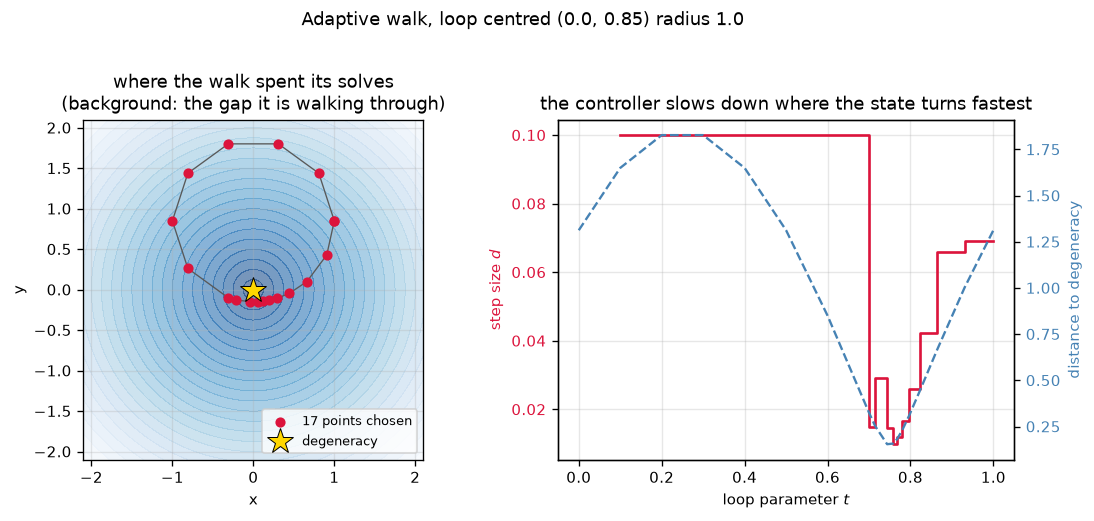

step sizes span 0.0098 to 0.1000  (ratio 10.2x)
phase = pi, theory says pi; agrees: True


In [2]:
centre, radius = (0.0, 0.85), 1.0
res, walk = jt_loop_adaptive(centre=centre, radius=radius)
ts = np.array(walk.t_values)
pts = np.array([(centre[0] + radius*np.cos(2*np.pi*t), centre[1] + radius*np.sin(2*np.pi*t))
                for t in ts])

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))

# --- left: the points the walk chose, on the loop, over the gap it was walking through ---
ax = axes[0]
g = np.linspace(-2.1, 2.1, 400)
X, Y = np.meshgrid(g, g)
ax.contourf(X, Y, 2*np.hypot(X, Y), levels=25, cmap="Blues_r", alpha=0.55)
ax.plot(pts[:, 0], pts[:, 1], "-", color="0.35", lw=0.8, zorder=2)
ax.scatter(pts[:, 0], pts[:, 1], s=26, c="crimson", zorder=3, label=f"{len(ts)-1} points chosen")
ax.plot(0, 0, "*", ms=16, color="gold", mec="k", mew=0.6, zorder=4, label="degeneracy")
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("where the walk spent its solves\n(background: the gap it is walking through)")
ax.legend(loc="lower right", fontsize=7.5)

# --- right: step size around the loop, against the distance to the degeneracy ---
ax = axes[1]
d = walk.step_sizes
t_mid = 0.5*(ts[:-1] + ts[1:])
dist = np.hypot(pts[:, 0], pts[:, 1])
ax.step(ts[1:], d, where="pre", color="crimson", lw=1.6, label="step size $d$")
ax.set_xlabel("loop parameter $t$"); ax.set_ylabel("step size $d$", color="crimson")
ax.tick_params(axis="y", labelcolor="crimson")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(ts, dist, color="steelblue", lw=1.4, ls="--", label="distance to degeneracy")
ax2.set_ylabel("distance to degeneracy", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax.set_title("the controller slows down where the state turns fastest")
fig.suptitle(f"Adaptive walk, loop centred {centre} radius {radius}", y=1.02)
plt.show()

print(f"step sizes span {d.min():.4f} to {d.max():.4f}  (ratio {d.max()/d.min():.1f}x)")
print(f"phase = {'pi' if res.is_nontrivial else '0'}, theory says "
      f"{'pi' if res.expected_nontrivial else '0'}; agrees: {res.agrees_with_theory}")

The two curves are mirror images by construction: the step size is smallest exactly where the loop
passes closest to the degeneracy, and it is not told where the degeneracy is. It infers it from the
overlaps it measures.

## 2. What a rejection looks like

With a deliberately over-large $d_\max$ the walk oversteps and has to back up. The rejected trials
are real CASSCF solves in the chemistry case, so they are charged to the cost — a comparison that
hid them would flatter the method.

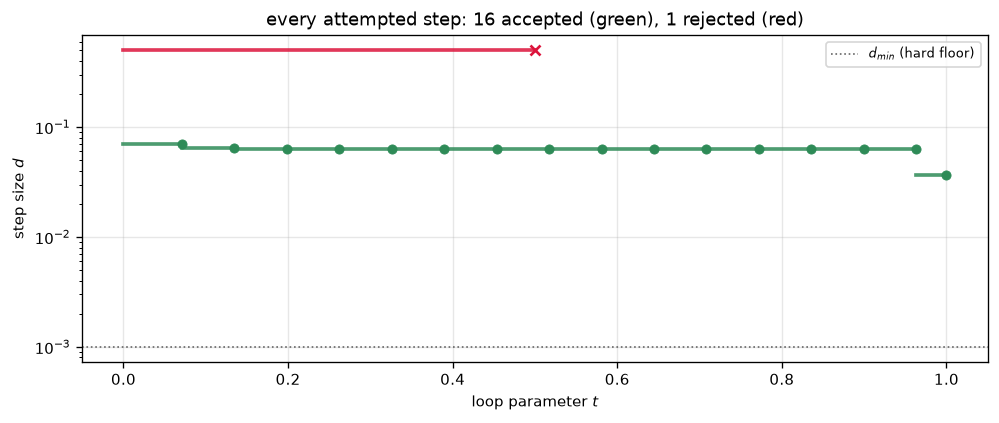

1 rejections out of 17 attempts.
A rejected trial is discarded completely: the walk retries from the SAME accepted state,
never from the trial. The previous state is never modified, which is the one correctness
requirement of a rejection and the one whose failure would be silent.


In [3]:
cfg_coarse = AdaptiveConfig(d_max=0.5, target_mismatch=0.02, accept_mismatch=0.05)
_, w2 = jt_loop_adaptive(centre=(0.0, 0.0), radius=1.0, cfg=cfg_coarse)

fig, ax = plt.subplots(figsize=(8.4, 3.6))
for e in w2.events:
    colour = "seagreen" if e.accepted else "crimson"
    ax.plot([e.t_from, e.t_to], [e.d, e.d], "-", color=colour, lw=2.2, alpha=0.85)
    ax.plot(e.t_to, e.d, "o" if e.accepted else "x", color=colour, ms=5.5,
            mew=1.6 if not e.accepted else 0.5)
ax.axhline(cfg_coarse.d_min, color="0.4", ls=":", lw=1, label="$d_{min}$ (hard floor)")
ax.set_yscale("log"); ax.set_xlabel("loop parameter $t$"); ax.set_ylabel("step size $d$")
ax.set_title(f"every attempted step: {w2.n_accepted} accepted (green), "
             f"{w2.n_rejected} rejected (red)")
ax.legend(fontsize=8)
plt.show()

print(f"{w2.n_rejected} rejections out of {len(w2.events)} attempts.")
print("A rejected trial is discarded completely: the walk retries from the SAME accepted state,")
print("never from the trial. The previous state is never modified, which is the one correctness")
print("requirement of a rejection and the one whose failure would be silent.")

Notice the shape: the walk oversteps, halves back, and then **settles** rather than oscillating.
That is the controller steering toward $m_\mathrm{target}$ instead of merely rejecting at the
threshold — a pure accept/reject rule would keep bouncing off the limit and pay a full solve each
time it did.

## 3. How close can a loop pass? A predicted limit, and a measurement

There is a hard limit on how near a degeneracy a loop can pass and still be walked. It can be
derived rather than discovered.

A loop of radius $R$ passing at distance $\varepsilon$ sweeps the state's angle at
$\mathrm{d}\theta/\mathrm{d}t \approx 2\pi R/\varepsilon$ near closest approach. Keeping the
per-step angle below $\Delta\theta_\max = 2\arccos(1 - m_\mathrm{accept})$ therefore needs a step of
about $\varepsilon\,\Delta\theta_\max/(2\pi R)$, and the walk gives up when that falls below
$d_\min$:

$$ \boxed{\;\varepsilon_\min \;\approx\; \frac{2\pi R\, d_\min}{\Delta\theta_\max}\;} $$

With the defaults ($d_\min = 10^{-3}$, $m_\mathrm{accept} = 0.1$) this is **0.7% of the loop
radius**. Below that the walk reports the floor instead of a phase.

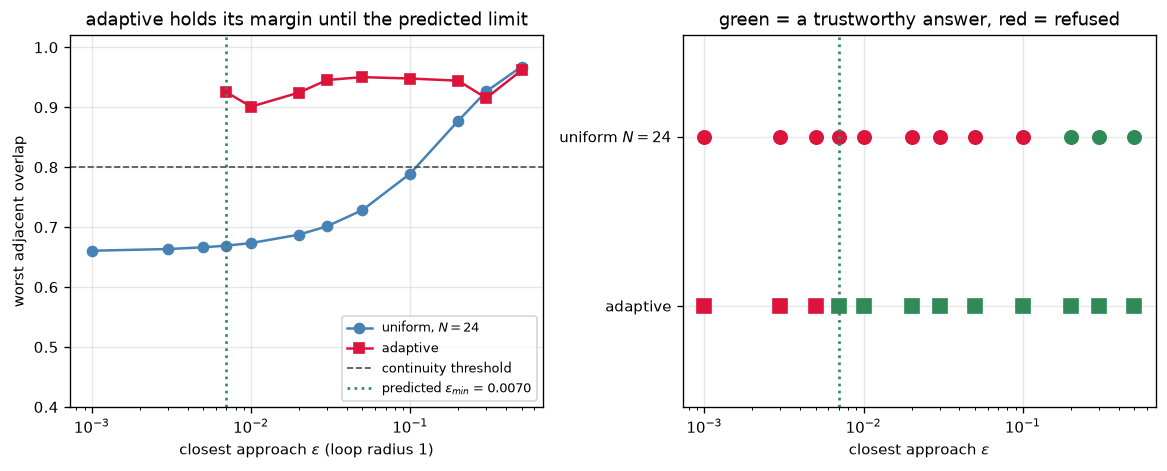

predicted floor          : eps = 0.0070
closest eps still walked : 0.007
largest eps that floored : 0.001

Uniform N=24 returns the CORRECT sign at every eps here, and fails its own continuity
check from eps = 0.1 inwards. Being right is not the same as being trustworthy:
a user without the answer would have to refuse those runs.


In [4]:
cfg = AdaptiveConfig()
dtheta_max = 2*np.arccos(1 - cfg.accept_mismatch)
eps_pred = 2*np.pi*1.0*cfg.d_min/dtheta_max

eps_list = [0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01, 0.007, 0.005, 0.003, 0.001]
rows = []
for eps in eps_list:
    c = (0.0, 1.0 - eps)
    u = jt_loop_berry_phase(centre=c, radius=1.0, n_points=24)
    r, w = jt_loop_adaptive(centre=c, radius=1.0)
    rows.append(dict(eps=eps,
                     u_ok=bool(u.min_abs_adjacent_overlap >= 0.80),
                     u_minovl=u.min_abs_adjacent_overlap, u_right=u.is_nontrivial,
                     a_floor=w.hit_step_floor, a_closed=w.closed,
                     a_minovl=r.min_abs_adjacent_overlap, a_pts=r.n_points,
                     a_right=r.is_nontrivial))

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.0))
ax = axes[0]
e = np.array([r["eps"] for r in rows])
ax.semilogx(e, [r["u_minovl"] for r in rows], "o-", color="steelblue",
            label="uniform, $N=24$")
ax.semilogx(e, [r["a_minovl"] if r["a_closed"] else np.nan for r in rows], "s-",
            color="crimson", label="adaptive")
ax.axhline(0.80, color="0.3", ls="--", lw=1, label="continuity threshold")
ax.axvline(eps_pred, color="seagreen", ls=":", lw=1.6,
           label=fr"predicted $\varepsilon_{{min}}$ = {eps_pred:.4f}")
ax.set_xlabel(r"closest approach $\varepsilon$ (loop radius 1)")
ax.set_ylabel("worst adjacent overlap"); ax.set_ylim(0.4, 1.02)
ax.set_title("adaptive holds its margin until the predicted limit")
ax.legend(fontsize=7.5, loc="lower right")

ax = axes[1]
for r in rows:
    y = 1 if r["u_ok"] else 0
    ax.plot(r["eps"], 1.0, "o", ms=8, color="seagreen" if r["u_ok"] else "crimson")
    ok_a = r["a_closed"] and not r["a_floor"]
    ax.plot(r["eps"], 0.0, "s", ms=8, color="seagreen" if ok_a else "crimson")
ax.set_xscale("log"); ax.set_yticks([0, 1])
ax.set_yticklabels(["adaptive", "uniform $N=24$"])
ax.axvline(eps_pred, color="seagreen", ls=":", lw=1.6)
ax.set_ylim(-0.6, 1.6); ax.set_xlabel(r"closest approach $\varepsilon$")
ax.set_title("green = a trustworthy answer, red = refused")
plt.show()

first_floor = min((r["eps"] for r in rows if r["a_floor"]), default=None)
last_ok = min((r["eps"] for r in rows if r["a_closed"] and not r["a_floor"]), default=None)
print(f"predicted floor          : eps = {eps_pred:.4f}")
print(f"closest eps still walked : {last_ok}")
print(f"largest eps that floored : {first_floor}")
print()
print("Uniform N=24 returns the CORRECT sign at every eps here, and fails its own continuity")
print("check from eps = 0.1 inwards. Being right is not the same as being trustworthy:")
print("a user without the answer would have to refuse those runs.")

### How many points would uniform stepping actually need?

The comparison above fixes $N = 24$, which is unfair in one direction: uniform stepping can always
be made to work by taking more points. So measure how many it needs to reach the *same* margin the
adaptive walk achieves.

In [5]:
print(f"{'eps':>7} {'uniform N for minovl>=0.90':>28} {'adaptive points':>17} {'ratio':>7}")
print("-" * 64)
for eps in (0.1, 0.05, 0.02, 0.007):
    c = (0.0, 1.0 - eps)
    need = None
    for N in (24, 50, 100, 200, 400, 700, 1000, 1500, 2200, 3000):
        if jt_loop_berry_phase(centre=c, radius=1.0, n_points=N).min_abs_adjacent_overlap >= 0.90:
            need = N
            break
    ra, _ = jt_loop_adaptive(centre=c, radius=1.0)
    ratio = f"{need/ra.n_points:.0f}x" if need else "--"
    print(f"{eps:>7.3f} {str(need):>28} {ra.n_points:>17} {ratio:>7}")

    eps   uniform N for minovl>=0.90   adaptive points   ratio
----------------------------------------------------------------
  0.100                          100                19      5x
  0.050                          200                20     10x
  0.020                          400                21     19x
  0.007                         1000                23     43x


This is the result that reconciles "cost-neutral" with "worth building". Adaptive stepping saves
nothing on a loop of uniform difficulty — and **19x to 43x** on a loop that passes close to a
degeneracy. The loops in the active-space studies are the former; the loops a *search* has to walk
are the latter, by construction, because a search deliberately probes near the thing it is looking
for.

The measurement lands on the prediction: the walk closes at $\varepsilon = 0.007$ and hits the
floor at $0.005$, against a predicted $0.0070$.

Two things worth taking from the right-hand panel:

* **Adaptive extends the trustworthy range by more than an order of magnitude** in closest
  approach — from $\varepsilon \approx 0.1$ to $\varepsilon \approx 0.007$ — while using 16–23
  points. A uniform walk would need $N \approx 1000$ to hold the same margin at $\varepsilon = 0.007$.
* **Uniform stepping is accidentally right long after it stops being trustworthy.** It returns the
  correct sign at every $\varepsilon$ tested, including ones where its worst overlap has collapsed
  to 0.66. Without knowing the answer in advance there is no way to tell those apart, which is
  exactly the distinction this project keeps insisting on.

This is what makes the bisection of `locating_intersections.ipynb` possible: that search spends its
time on loops that pass deliberately close to a degeneracy.

## 4. The informative failure

A loop through the degeneracy cannot be walked at any step size, and the walk should say so rather
than return a sign that happens to have one.

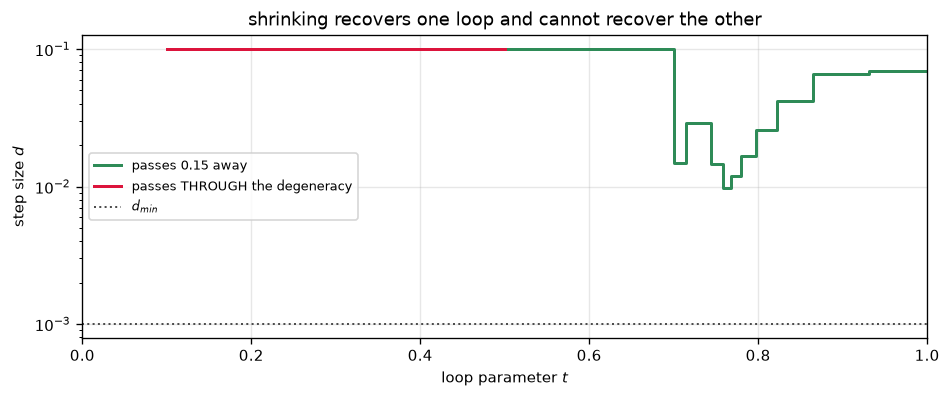

near     : closed=True   floor=False
through  : closed=False  floor=True

The second walk stops partway and reports the floor. It does NOT report a phase.
The message names both possible causes -- the loop passing through a degeneracy, or the
solver switching between nearby stationary solutions -- because the walk cannot tell
them apart and should not pretend to.


In [6]:
_, w_through = jt_loop_adaptive(centre=(1.0, 0.0), radius=1.0)   # passes exactly through (0,0)
_, w_near    = jt_loop_adaptive(centre=(0.0, 0.85), radius=1.0)  # passes 0.15 away

fig, ax = plt.subplots(figsize=(8.0, 3.4))
for w, name, col in ((w_near, "passes 0.15 away", "seagreen"),
                     (w_through, "passes THROUGH the degeneracy", "crimson")):
    acc = [(e.t_to, e.d) for e in w.accepted_events]
    ax.step([a[0] for a in acc], [a[1] for a in acc], where="pre", color=col, lw=1.8, label=name)
ax.axhline(AdaptiveConfig().d_min, color="0.3", ls=":", lw=1.2, label="$d_{min}$")
ax.set_yscale("log"); ax.set_xlabel("loop parameter $t$"); ax.set_ylabel("step size $d$")
ax.set_xlim(0, 1); ax.legend(fontsize=8)
ax.set_title("shrinking recovers one loop and cannot recover the other")
plt.show()

print(f"near     : closed={w_near.closed}   floor={w_near.hit_step_floor}")
print(f"through  : closed={w_through.closed}  floor={w_through.hit_step_floor}")
print()
print("The second walk stops partway and reports the floor. It does NOT report a phase.")
print("The message names both possible causes -- the loop passing through a degeneracy, or the")
print("solver switching between nearby stationary solutions -- because the walk cannot tell")
print("them apart and should not pretend to.")

### A failure this caught in the real code

An early version of this walk had a hole in exactly this place. When the step floor stopped the
walk partway round, the run still came back **`status OK`, phase `trivial (0)`** — because the
endpoint checks are skipped when there is no endpoint, every *accepted* step was continuous, and
$|\langle\Psi_\mathrm{last}|\Psi_0\rangle|$ — the single factor carrying the sign of the product
estimator — was never checked at all. The unclosed path was silently treated as a loop.

Two checks now cover it (`loop_closed`, `closing_step_continuous`), and both are regression-tested.
A uniform walk closes by construction and pays nothing for them. It is worth being explicit that
this bug was *not* found by reasoning about the code — it was found because a figure showed a
verdict that could not be right.

## 5. Does it pay on real CASSCF?

The honest answer is **it depends on the loop, and on formaldimine it does not.**

The comparison is a *family against a family*. Adaptive stepping has knobs ($d_\max$,
$m_\mathrm{target}$) and uniform stepping has $N$; comparing one setting of each would prove
nothing, since either can be made to look good by choosing its parameter well. Both are swept.

Cost is counted in **micro-iterations** — CASSCF parameter updates — because wall time carries
per-point overhead that differs between machines. Rejected adaptive trials are charged in full.

In [7]:
form = load("results/adaptive/formaldimine_stepping.json")
buta = load("results/adaptive/butadiene_stepping.json")
eth  = load("results/adaptive/ethylene_stepping.json")

def frontier_table(data, title):
    if not data:
        print(f"{title}: not run yet"); return
    print(f"\n{title}")
    print(f"{'loop':>5} {'CAS':>10} {'target ovl':>10} {'uniform':>20} {'adaptive':>22} {'ratio':>7}")
    print("-" * 80)
    for q in data["matched_quality"]:
        u, a = q["uniform_micro"], q["adaptive_micro"]
        ratio = f"{u/a:.2f}x" if (u and a) else "--"
        us = f"{u} ({q['uniform_setting']})" if u else "none passes"
        as_ = f"{a} ({q['adaptive_setting'].split(',')[0]})" if a else "none passes"
        print(f"{q['loop']:>5} {q['cas']:>10} {q['target']:>10.2f} {us:>20} {as_:>22} {ratio:>7}")

frontier_table(form, "FORMALDIMINE / STO-3G      -- cost (micro-iterations) at matched quality")
frontier_table(buta, "BUTADIENE CAS(2,2) / 6-31G* -- cost (micro-iterations) at matched quality")
frontier_table(eth,  "ETHYLENE CAS(8,8) / 6-31G*  -- the largest PREDICTED saving, 4.7x")


FORMALDIMINE / STO-3G      -- cost (micro-iterations) at matched quality
 loop        CAS target ovl              uniform               adaptive   ratio
--------------------------------------------------------------------------------
  C_2   CAS(2,2)       0.90            127 (N=9)         103 (dmax=0.2)   1.23x
  C_2   CAS(2,2)       0.95            127 (N=9)         138 (dmax=0.1)   0.92x
  C_2   CAS(2,2)       0.98           164 (N=13)         138 (dmax=0.1)   1.19x
  C_x   CAS(2,2)       0.90            351 (N=9)         587 (dmax=0.1)   0.60x
  C_x   CAS(2,2)       0.95           482 (N=13)         587 (dmax=0.1)   0.82x
  C_x   CAS(2,2)       0.98           797 (N=25)            none passes      --
  C_2   CAS(6,6)       0.90            220 (N=9)         287 (dmax=0.1)   0.77x
  C_2   CAS(6,6)       0.95            220 (N=9)         287 (dmax=0.1)   0.77x
  C_2   CAS(6,6)       0.98           473 (N=13)         392 (dmax=0.1)   1.21x
  C_x   CAS(6,6)       0.90           735 (N=

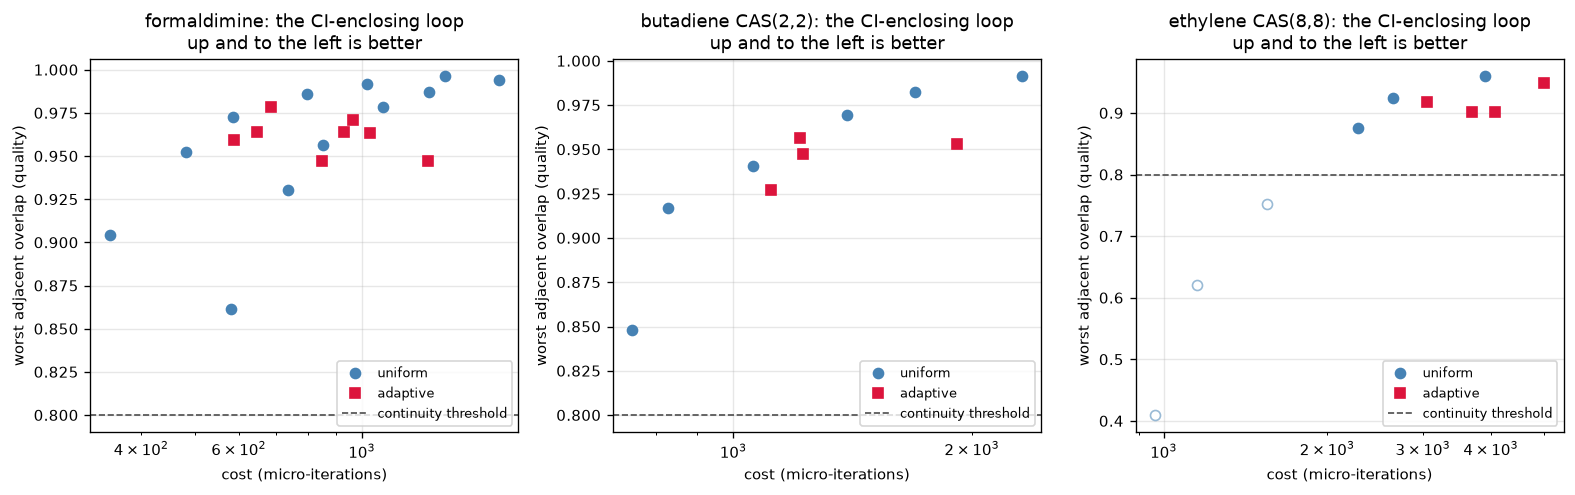

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), squeeze=False)
for ax, data, title in zip(axes[0], (form, buta, eth),
                           ("formaldimine", "butadiene CAS(2,2)", "ethylene CAS(8,8)")):
    if not data:
        ax.text(0.5, 0.5, f"{title}\nnot run yet", ha="center", va="center"); ax.axis("off")
        continue
    for method, colour, marker in (("uniform", "steelblue", "o"), ("adaptive", "crimson", "s")):
        rows = [r for r in data["rows"] if r["method"] == method and r["status"] == "OK"
                and r["loop"].endswith("_x")]
        # the refused runs matter too: they are where uniform stepping cannot be trusted
        bad = [r for r in data["rows"] if r["method"] == method and r["status"] != "OK"
               and r["loop"].endswith("_x")]
        if bad:
            ax.plot([r["micro"] for r in bad], [r["min_overlap"] for r in bad],
                    marker, color=colour, ms=6, ls="none", mfc="none", alpha=0.55)
        if not rows: continue
        ax.plot([r["micro"] for r in rows], [r["min_overlap"] for r in rows],
                marker, color=colour, ms=6, ls="none", label=method)
    ax.axhline(0.80, color="0.3", ls="--", lw=1, label="continuity threshold")
    ax.set_xscale("log"); ax.set_xlabel("cost (micro-iterations)")
    ax.set_ylabel("worst adjacent overlap (quality)")
    ax.set_title(f"{title}: the CI-enclosing loop\nup and to the left is better")
    ax.legend(fontsize=7.5, loc="lower right")
plt.show()

### Why the predicted saving did not materialise

The predictions (1.3x-4.7x) were made from the *spread of adjacent overlaps* on saved runs, on the
assumption that cost is proportional to the number of points. Two measured effects break that
assumption, and both work against adaptive stepping.

**1. Hard points cost more to solve.** The points where the state turns fastest are also the ones
where CASSCF needs the most iterations - so removing easy points removes the *cheap* ones, and
adding points near the degeneracy adds the *expensive* ones.

In [9]:
from berrycasscf import CasConfig, LOOP_CI
from berrycasscf.continuation import traverse_loop

print("per-point solver cost against per-point difficulty, on one uniform N=33 walk:")
print(f"{'system':>22} {'r(overlap, micro)':>18} {'hard half':>11} {'easy half':>11} {'ratio':>7}")
print("-" * 74)
for ncas, ne, lbl in ((2, 2, "formaldimine CAS(2,2)"), (6, 6, "formaldimine CAS(6,6)")):
    tr = traverse_loop(LOOP_CI.with_n_points(33), cas=CasConfig(ncas=ncas, nelecas=ne))
    pts = [p for p in tr.points if p.abs_overlap_with_prev is not None]
    ov = np.array([p.abs_overlap_with_prev for p in pts])
    mi = np.array([p.n_micro for p in pts], float)
    r = np.corrcoef(ov, mi)[0, 1]
    order = np.argsort(ov); h = len(pts) // 2
    hard, easy = mi[order[:h]].mean(), mi[order[h:]].mean()
    print(f"{lbl:>22} {r:>18.2f} {hard:>11.1f} {easy:>11.1f} {hard/easy:>6.2f}x")
print()
print("Negative r: the lower the adjacent overlap, the more micro-iterations that point cost.")

per-point solver cost against per-point difficulty, on one uniform N=33 walk:
                system  r(overlap, micro)   hard half   easy half   ratio
--------------------------------------------------------------------------


 formaldimine CAS(2,2)              -0.40        33.6        27.9   1.20x


 formaldimine CAS(6,6)              -0.67        35.8        32.3   1.11x

Negative r: the lower the adjacent overlap, the more micro-iterations that point cost.


**2. Rejections are not free.** A rejected trial is a full CASSCF solve that produces nothing. The
runs above reject 1-7 times on the harder loops, and those solves are charged in full, as they must
be. The controller steers toward $m = 0.02$ while refusing only above $0.10$ precisely to keep
rejections rare, but the $m \sim d^2$ model is evidently imperfect for a CASSCF wavefunction and it
still oversteps.

### The decomposition, on the loop that was supposed to be the best case

Ethylene `E_x` at CAS(8,8) was predicted to save **4.7x** - the largest of any loop in the project,
estimated from its adjacent-overlap spread (worst 0.855, median 0.994). At matched quality it comes
out at **0.87x**. The two numbers that explain it, taken from the adaptive run with *zero*
rejections so the second mechanism is excluded entirely:

| | uniform $N=33$ | adaptive $d_{max}=0.05$ |
|---|---|---|
| points | 33 | 26  (**0.79x**) |
| micro-iterations per point | 80.2 | 117.6  (**1.47x**) |
| total micro-iterations | 2647 | 3058  (1.16x) |
| worst adjacent overlap | 0.9243 | 0.9187 |

**The point-count saving is real and is simply outweighed.** Adaptive uses 21% fewer points and
each costs 47% more, because they sit where the solver has to work hardest. The prediction assumed
a constant cost per point; that assumption, not the controller, is what failed.

### Verdict

**Adaptive stepping never beat uniform discretization on cost, on any CASSCF loop tested.**

| system | loops | measured, at matched quality |
|---|---|---|
| formaldimine STO-3G, CAS(2,2) and CAS(6,6) | `C_x`, `C_2` | 0.60x – 1.23x |
| butadiene 6-31G\*, CAS(2,2) | `B_x`, `B_2` | 0.67x – 1.15x |
| ethylene 6-31G\*, CAS(8,8) | `E_x`, `E_2` | 0.75x – 1.04x |

The predictions made beforehand from adjacent-overlap spreads were 1.3x, 3.1x and **4.7x**. All
three are wrong, and the largest prediction belongs to the loop that did worst against it. That
prediction is retracted. The reason is measured above and is not subtle: **cost is not proportional
to the number of points**, and the points adaptive adds are the expensive ones.

**Where step control does pay is on loops that pass close to a degeneracy**, and there it pays
enormously — 19x fewer points at a closest approach of 0.02 of the loop radius, 43x at 0.007. Those
are not the loops in the active-space studies, which is why the CASSCF numbers above are flat. They
*are* the loops a search has to walk, because a search probes near the thing it is looking for.

Three further reasons, none of them speed:

* **loops uniform stepping cannot walk at any affordable $N$** — the trustworthy range extends by
  more than an order of magnitude in closest approach. This is the difference between an answer and
  a refusal, and it is what makes `locating_intersections.ipynb` possible;
* **not having to guess $N$ in advance.** A uniform run needs $N$ chosen before anything is known
  about the loop, and the project's own history contains several runs refused purely for having
  guessed it too low;
* **an automatic diagnosis** of *why* a loop failed — undersampled, or passing through something.